# Лабораторная работа 4. Математика CNN и FGSM-атаки
# Стрельченко Алексей Александрович

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## 0. Подготовка окружения

**Тензор** — это многомерный массив чисел. Изображение MNIST — тензор формы [batch, channels, height, width]. Свёрточная сеть работает именно с такими четырёхмерными тензорами.

Вычисления можно проводить на CPU или GPU (CUDA). GPU в десятки раз быстрее для матричных операций, которые лежат в основе CNN. Мы выбираем устройство автоматически.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

**Свёртка** — операция, при которой маленькое окно (ядро) размера k × k скользит по входу. На каждом шаге считается скалярное произведение весов ядра на участок входа. Результат записывается в выходную карту.

Параметры, влияющие на размер выхода:
k — размер ядра (kernel size). Чем больше, тем больше контекст видит нейрон.
s — шаг (stride). На сколько пикселей окно свёртки сдвигается за один шаг. При s > 1 выход уменьшается.
p — padding (отступ). Сколько нулей добавляется по краям. Нужен, чтобы сохранить размер или учесть краевые пиксели.

Числитель H − k + 2p — это полная длина, по которой может скользить окно после добавления padding. Деление на s даёт число возможных позиций. Плюс один — потому что первая позиция тоже считается.

In [ ]:
# TODO: реализуйте функцию
def conv_output_size(H, k, s, p):
    # H — входной размер (высота или ширина), k — размер ядра,
    # s — шаг (stride), p — padding (отступ)
    return (H - k + 2 * p) // s + 1

# Рассчитайте H_out для следующих конфигураций и заполните таблицу результатов
configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]

# TODO: примените conv_output_size ко всем конфигурациям и выведите результат
for c in configs:
    out = conv_output_size(c["H"], c["k"], c["s"], c["p"])
    print(f"H={c['H']}, k={c['k']}, s={c['s']}, p={c['p']} -> H_out={out}")

H=224, k=7, s=2, p=3 -> H_out=112
H=224, k=3, s=1, p=1 -> H_out=224
H=56, k=3, s=2, p=1 -> H_out=28
H=28, k=5, s=1, p=0 -> H_out=24


### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

(то есть каждый новый слой добавляет (k-1), умноженное на произведение всех предыдущих stride.)

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

**Рецептивное поле (RF)** — это область исходного изображения, которая влияет на один нейрон выходной карты. Чем глубже слой, тем больше RF.

In [4]:
# TODO: реализуйте функцию
def receptive_field(layers):
    # layers — список пар (kernel_size, stride)
    rf = 1
    stride_prod = 1
    for k, s in layers:
        rf = rf + (k - 1) * stride_prod
        stride_prod *= s
    return rf

# Вариант А: три слоя 3x3 (stride=1)
layers_a = [(3, 1), (3, 1), (3, 1)]
# Вариант Б: один слой 7x7 (stride=1)
layers_b = [(7, 1)]

# TODO: рассчитайте RF для обоих вариантов и сравните
rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)
print(f"RF варианта А (3x3 x3): {rf_a}")
print(f"RF варианта Б (7x7 x1): {rf_b}")

RF варианта А (3x3 x3): 7
RF варианта Б (7x7 x1): 7


Оба варианта дают RF = 7. Это и есть аргумент VGG: стек из трёх ядер 3×3 эквивалентен одному ядру 7×7 по рецептивному полю.

In [5]:
# TODO: рассчитайте и сравните число обучаемых параметров для вариантов А и Б
# при числе входных/выходных каналов C = 64 (без учёта bias)
# Формула для k x k свёртки с C входными и C выходными каналами: k^2 * C^2

C = 64
params_a = 3 * (3 * 3 * C * C)   # три свёртки 3x3
params_b = 1 * (7 * 7 * C * C)   # одна свёртка 7x7
print(f"Параметров в А: {params_a:,}")
print(f"Параметров в Б: {params_b:,}")
print(f"Отношение Б/А: {params_b / params_a:.2f}")

Параметров в А: 110,592
Параметров в Б: 200,704
Отношение Б/А: 1.81


**Вопрос для отчёта:** при одинаковом рецептивном поле какой вариант (А или Б) эффективнее по числу параметров и почему? Как это соотносится с архитектурным принципом VGG?

**Мой ответ:** Вариант А эффективнее, потому что три слоя по 3×3 имеют в сумме 3·9 = 27 весов на канал, а один слой 7×7 — 49 весов.
VGG использует именно этот принцип: заменяет большие ядра на стеки маленьких 3×3, что уменьшает число параметров, добавляет нелинейности (ReLU между слоями) и повышает выразительность сети.

### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

_Ручной расчёт рецептивного поля вашей архитектуры (формулы и числа):_  

Вход у нас картинка 28 на 28 пикселей, один канал, потому что MNIST чёрно-белый.

Вход — картинка 28×28, 1 канал, потому что MNIST чёрно-белый.

Беру два свёрточных слоя. Для такой простой задачи этого хватает, больше слоёв только замедлят обучение.

Первый свёрточный слой: ядро 3×3, stride=1, padding=1. Ядро 3×3 ловит простые узоры вроде штрихов и углов. Padding=1 нужен, чтобы размер карты не уменьшался после свёртки. Stride=1, чтобы ничего не терять. Выходных карт 16, то есть 16 разных ядер, каждое ищет свой узор.

После первого слоя ставлю MaxPool 2×2. Он уменьшает карту вдвое: 28×28 → 14×14. Оставляет самые сильные сигналы. Это уменьшает вычисления и делает сеть устойчивее к небольшим сдвигам цифры.

Второй свёрточный слой: тоже ядро 3×3, stride=1, padding=1. На входе 16 карт, на выходе 32. Слой комбинирует предыдущие 16 карт и ловит более сложные узоры, не отдельные штрихи, а их сочетания.

После второго слоя снова MaxPool 2×2. Размер становится 7×7, каналов по-прежнему 32.

Дальше разворачиваю тензор в вектор длины 32·7·7 = 1568. Первый полносвязный слой сжимает 1568 чисел до 128. Второй полносвязный слой выдаёт 10 чисел, по одному на каждую цифру от 0 до 9.

**Ручной расчёт рецептивного поля**
Рецептивное поле — это размер области исходной картинки, которую видит один нейрон. Формула: RF = RF_пред + (k − 1)·произведение_предыдущих_stride. Начинаю с RF = 1.

До первого слоя: RF = 1.

После первого свёрточного слоя: k=3, stride=1, произведение stride = 1. RF = 1 + (3 − 1)·1 = 3.

После первого MaxPool 2×2: k=2, stride=2. RF = 3 + (2 − 1)·1 = 4. Произведение stride стало 1·2 = 2.

После второго свёрточного слоя: k=3, stride=1, произведение stride = 2. RF = 4 + (3 − 1)·2 = 8.

После второго MaxPool 2×2: k=2, stride=2. RF = 8 + (2 − 1)·4 = 12. Произведение stride стало 1·2·1·2 = 4.

Итоговое рецептивное поле перед классификатором — 12×12 пикселей исходного изображения. Каждый нейрон после второго пулинга видит квадрат 12×12 исходной картинки. Для цифры 28×28 это почти половина изображения, этого хватает, чтобы уверенно различать цифры.

In [6]:
class MyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()  # обязательный вызов конструктора родителя nn.Module

        # Первый свёрточный блок: свёртка → MaxPool
        # Conv2d(1, 16, 3, 1, 1) — 1 входной канал, 16 выходных карт,
        # ядро 3×3, stride=1, padding=1 (размер карты сохраняется 28×28)
        # MaxPool2d(2) — уменьшает размер вдвое: 28×28 → 14×14
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # [B, 1, 28, 28] → [B, 16, 28, 28]
            nn.MaxPool2d(2)                                         # [B, 16, 28, 28] → [B, 16, 14, 14]
        )

        # Второй свёрточный блок: свёртка → MaxPool
        # Conv2d(16, 32, 3, 1, 1) — 16 входных карт, 32 выходных,
        # ядро 3×3, stride=1, padding=1 (размер сохраняется 14×14)
        # MaxPool2d(2) — уменьшает вдвое: 14×14 → 7×7
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # [B, 16, 14, 14] → [B, 32, 14, 14]
            nn.MaxPool2d(2)                                         # [B, 32, 14, 14] → [B, 32, 7, 7]
        )

        # Классификатор: flatten → скрытый слой → выходной слой
        # Flatten разворачивает [B, 32, 7, 7] в вектор [B, 1568]
        # Linear(1568, 128) — сжимает 1568 признаков до 128
        # Linear(128, 10) — выходной слой, 10 логитов (по одному на цифру 0..9)
        # Без softmax — CrossEntropyLoss добавит его сам внутри
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # [B, 32, 7, 7] → [B, 1568]
            nn.Linear(32 * 7 * 7, 128),      # 1568 → 128
            nn.Linear(128, num_classes)      # 128 → 10 классов
        )

    def forward(self, x):
        # Прогоняем вход через два свёрточных блока, потом через классификатор
        x = self.conv_block1(x)   # [B, 1, 28, 28] → [B, 16, 14, 14]
        x = self.conv_block2(x)   # [B, 16, 14, 14] → [B, 32, 7, 7]
        x = self.classifier(x)    # [B, 32, 7, 7] → [B, 10]
        return x

## Часть II. Данные и обучение базовой модели

In [7]:
# TODO: загрузите MNIST через torchvision.datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 449kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.38MB/s]


In [8]:
# TODO: обучите вашу модель MyCNN на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = MyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# TODO: цикл обучения

def train_one_epoch(model, loader, optimizer, criterion):
    # Переключаем модель в режим обучения
    model.train()
    # Сюда накапливаем суммарный лосс за эпоху
    total_loss = 0
    # Идём по батчам из DataLoader
    for x, y in loader:
        # Переносим батч изображений и меток на device
        x, y = x.to(device), y.to(device)
        # Обнуляем градиенты с прошлого шага, иначе они накопятся
        optimizer.zero_grad()
        # Прямой проход: получаем логиты формы [B, 10]
        logits = model(x)
        # Считаем лосс между логитами и истинными метками
        loss = criterion(logits, y)
        # Обратный проход: считаем градиенты по всем параметрам
        loss.backward()
        # Шаг оптимизатора: обновляем веса в направлении антиградиента
        optimizer.step()
        # Накапливаем лосс, умноженный на размер батча
        total_loss += loss.item() * x.size(0)
    # Возвращаем средний лосс на один пример
    return total_loss / len(loader.dataset)

# Обучаем 3 эпохи
for epoch in range(3):
    # Одна эпоха обучения, возвращает средний лосс
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    # Печатаем номер эпохи и лосс
    print(f"Epoch {epoch+1}: loss={loss:.4f}")

Epoch 1: loss=0.2499
Epoch 2: loss=0.0865
Epoch 3: loss=0.0868


In [9]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
# Сохраните значение в переменную clean_accuracy для дальнейшего использования

def evaluate_accuracy(model, loader):
    # Режим инференса: отключает dropout и batchnorm-поведение обучения
    model.eval()
    # Счётчики правильных ответов и общего числа примеров
    correct, total = 0, 0
    # Градиенты не нужны — экономим память
    with torch.no_grad():
        # Идём по батчам
        for x, y in loader:
            # Переносим данные на device
            x, y = x.to(device), y.to(device)
            # Предсказанный класс — индекс максимума логитов
            pred = model(x).argmax(dim=1)
            # Считаем совпадения с истинными метками
            correct += (pred == y).sum().item()
            # Накапливаем размер батча
            total += y.size(0)
    # Доля правильных ответов
    return correct / total

# Точность на чистых тестовых данных
clean_accuracy = evaluate_accuracy(model, test_loader)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9772


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

Fast Gradient Sign Method — самый простой способ построить adversarial-пример. Идея: мы хотим изменить картинку так, чтобы лосс модели вырос максимально. Градиент лосса по входу показывает, в какую сторону менять каждый пиксель, чтобы лосс рос. Чтобы изменение было как можно эффективнее при ограничении «не больше ε на пиксель», берём знак градиента и умножаем на ε.



In [10]:
# TODO: реализуйте функцию FGSM-атаки

def fgsm_attack(model, x, y, epsilon=0.3):
    # Копируем картинки и говорим PyTorch: считай градиент по x (по пикселям, не по весам)
    x = x.clone().detach().requires_grad_(True)

    logits = model(x)              # прогон через сеть
    loss = criterion(logits, y)    # считаем ошибку
    loss.backward()                # обратный проход: получаем x.grad — как менять пиксели, чтобы loss вырос

    # Сдвигаем каждый пиксель на epsilon в сторону знака градиента
    x_adv = x + epsilon * x.grad.sign()

    # Обрезаем значения в [0, 1], чтобы пиксели остались корректными
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()   # возвращаем без графа вычислений

### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

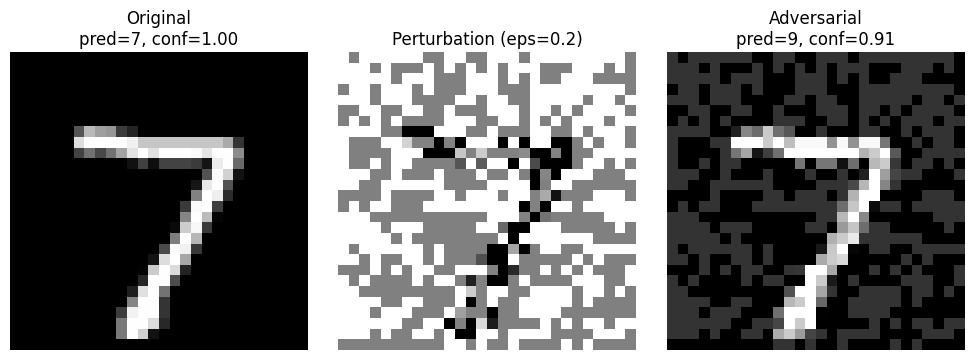

True label: 7


In [11]:
# TODO: выберите пример из test_loader
# TODO: примените fgsm_attack
# TODO: получите предсказания модели на оригинале и adversarial-примере (класс + confidence через softmax)
# TODO: постройте matplotlib-визуализацию из 3 подграфиков


model.eval()
# Берём первый батч из тестовой выборки
for x_batch, y_batch in test_loader:
    break

# Оставляем один пример
# x_batch имеет форму [128, 1, 28, 28] — 128 картинок в батче
# Срез [0:1] берёт только первую картинку, но сохраняет размерность батча: [1, 1, 28, 28]
# Это важно, потому что модель ожидает батч, пусть даже из одного примера
x0 = x_batch[0:1].to(device)
# То же самое для метки: было [128], стало [1] — метка для первой картинки
y0 = y_batch[0:1].to(device)

epsilon = 0.2
# Строим adversarial-пример
x_adv = fgsm_attack(model, x0, y0, epsilon)
# Возмущение = разница между adversarial и оригиналом
perturbation = (x_adv - x0).detach().squeeze().numpy()

# Считаем предсказания и уверенность для оригинала и adversarial
with torch.no_grad():
    logits_clean = model(x0)
    logits_adv   = model(x_adv)
    prob_clean = F.softmax(logits_clean, dim=1)[0]
    prob_adv   = F.softmax(logits_adv,   dim=1)[0]
    pred_clean = prob_clean.argmax().item()
    pred_adv   = prob_adv.argmax().item()
    conf_clean = prob_clean[pred_clean].item()
    conf_adv   = prob_adv[pred_adv].item()

# Рисуем три картинки: оригинал, возмущение, adversarial
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(x0.cpu().squeeze(), cmap="gray")
axes[0].set_title(f"Original\npred={pred_clean}, conf={conf_clean:.2f}")
axes[1].imshow(perturbation, cmap="gray")
axes[1].set_title(f"Perturbation (eps={epsilon})")
axes[2].imshow(x_adv.cpu().squeeze(), cmap="gray")
axes[2].set_title(f"Adversarial\npred={pred_adv}, conf={conf_adv:.2f}")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
print(f"True label: {y0.item()}")

**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

**Мой ответ**:  Предсказание удалось изменить. На чистом изображении модель уверенно распознала цифру 7 с вероятностью 1.00. На adversarial-версии модель предсказала 9 с вероятностью 0.91. То есть атака не только поменяла класс, но и сделала это с высокой уверенностью — модель «уверена» в неправильном ответе. Возмущение визуально заметно: при ε = 0.2 оно выглядит как отчётливый серый шум поверх цифры. Это связано с тем, что изображения MNIST маленькие (28×28) и одноканальные, поэтому возмущение на каждом пикселе хорошо видно глазу. На более крупных цветных картинках такое же по величине ε было бы почти незаметно, потому что эффект распределяется по сотням тысяч пикселей и трём каналам.

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

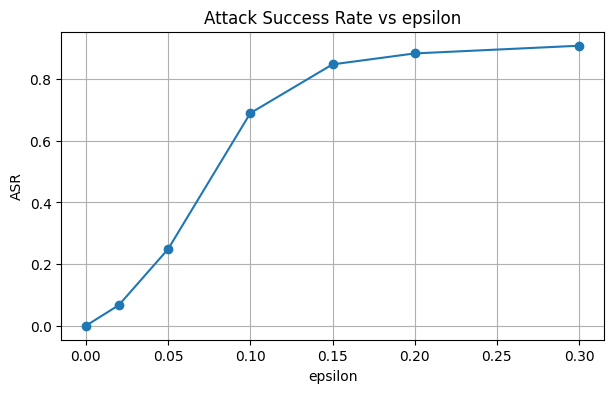

eps=0.00: ASR=0.000
eps=0.02: ASR=0.067
eps=0.05: ASR=0.249
eps=0.10: ASR=0.690
eps=0.15: ASR=0.848
eps=0.20: ASR=0.884
eps=0.30: ASR=0.909


In [12]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
def evaluate_asr(model, loader, epsilon, n_batches=10):
    model.eval()
    total, fooled = 0, 0
    for i, (x, y) in enumerate(loader):
        # Ограничиваем число батчей для скорости
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)
        # Предсказание на чистом примере
        with torch.no_grad():
            pred_clean = model(x).argmax(dim=1)
        # Строим adversarial-пример (или оставляем как есть при ε=0)
        if epsilon > 0:
            x_adv = fgsm_attack(model, x, y, epsilon)
        else:
            x_adv = x
        # Предсказание на adversarial
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(dim=1)
        # Считаем, сколько предсказаний изменилось
        fooled += (pred_adv != pred_clean).sum().item()
        total  += y.size(0)
    return fooled / total

# Набор бюджетов атаки
epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
# Считаем ASR для каждого ε
asr_list = [evaluate_asr(model, test_loader, e) for e in epsilons]

# Рисуем график ASR(ε)
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_list, marker="o")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("Attack Success Rate vs epsilon")
plt.grid(True); plt.show()
for e, a in zip(epsilons, asr_list):
    print(f"eps={e:.2f}: ASR={a:.3f}")

**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

**Мой ответ**:ASR начинает быстро расти в диапазоне ε от 0.05 до 0.10. При ε = 0.05 он равен 0.249, а при ε = 0.10 уже 0.690 — то есть доля обманутых примеров почти утроилась при удвоении бюджета. Дальше рост замедляется: при ε = 0.15 ASR = 0.848, при 0.20 — 0.884, при 0.30 — 0.909. Это типичное поведение FGSM: сначала резкий рост, потом выход на плато.
На картинках 28×28 и одном канале каждый пиксель меняется сильно, и глаз это замечает. На более крупных цветных изображениях то же значение ε было бы почти незаметно, потому что эффект распределяется по сотням тысяч пикселей. То есть для MNIST диапазон, где ASR уже высокий, а возмущение ещё незаметно, практически отсутствует: чуть заметный шум даёт лишь небольшой ASR, а существенный ASR требует уже видимых искажений.

## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.

На каждом шаге обучения мы сначала строим FGSM-пример для текущего батча, потом считаем лосс и на чистом, и на adversarial-примере, и обновляем веса так, чтобы уменьшить оба лосса одновременно.

Здесь α — вес чистого лосса. При α = 0.5 вклад чистого и adversarial-лосса одинаковый. Если α ближе к 1, модель больше внимания уделяет чистым данным, и устойчивость слабее. Если α ближе к 0, модель больше тренируется на adversarial-примерах, устойчивость выше, но чистая точность падает.

Обычно берут то же ε, что и при тестировании, или чуть меньше. Если обучать на слишком маленьком ε, модель не защитится от более сильных атак. Если на слишком большом, чистая точность сильно упадёт. 

Три минуса. Первое: чистая точность немного падает, потому что модель тратит часть ёмкости на устойчивость, а не только на распознавание. Второе: обучение идёт дольше, потому что на каждом шаге нужно ещё раз прогнать батч через модель для построения adversarial-примеров. Третье: устойчивость работает только против той атаки, на которой обучали (и на более простые по иерархии). FGSM-adversarial training защищает от FGSM, но более сильные атаки (итеративные, PGD) могут её пробить.

In [13]:
# TODO: реализуйте цикл adversarial training
# На каждом шаге:
# 1. Постройте x_adv через fgsm_attack для текущего батча
# 2. Посчитайте комбинированный loss (alpha * loss_clean + (1-alpha) * loss_adv)
# 3. Сделайте шаг оптимизации

# Создаём вторую модель той же архитектуры
adv_model = MyCNN().to(device)
# Оптимизатор для неё
adv_optimizer = torch.optim.Adam(adv_model.parameters(), lr=0.01)
# Вес чистого лосса: 0.5 — вклад чистого и adversarial равный
alpha = 0.5
# Бюджет атаки при обучении: среднее значение из п.3.3
eps_train = 0.1

def train_one_epoch_adv(model, loader, optimizer, criterion, eps, alpha):
    # Режим обучения
    model.train()
    total_loss = 0
    # Идём по батчам
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # Строим adversarial-пример для текущего батча
        x_adv = fgsm_attack(model, x, y, eps)
        # Прямой проход на чистых данных
        logits_clean = model(x)
        # Прямой проход на adversarial данных
        logits_adv = model(x_adv)
        # Комбинированный лосс
        loss = alpha * criterion(logits_clean, y) + (1 - alpha) * criterion(logits_adv, y)
        # Обнуляем градиенты
        optimizer.zero_grad()
        # Обратный проход
        loss.backward()
        # Шаг оптимизатора
        optimizer.step()
        # Накапливаем лосс
        total_loss += loss.item() * x.size(0)
    # Средний лосс на пример
    return total_loss / len(loader.dataset)

# Обучаем 3 эпохи
for epoch in range(3):
    loss = train_one_epoch_adv(adv_model, train_loader, adv_optimizer, criterion, eps_train, alpha)
    print(f"Adv epoch {epoch+1}: loss={loss:.4f}")

Adv epoch 1: loss=0.3773
Adv epoch 2: loss=0.2364
Adv epoch 3: loss=0.2182


Adv model clean accuracy: 0.9811


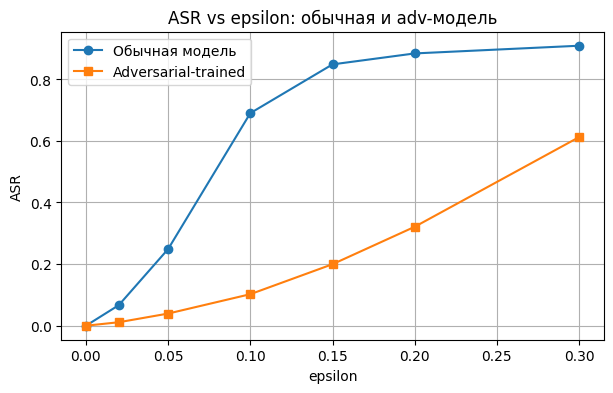

eps=0.00: ASR обычной=0.000, ASR adv=0.000
eps=0.02: ASR обычной=0.067, ASR adv=0.011
eps=0.05: ASR обычной=0.249, ASR adv=0.039
eps=0.10: ASR обычной=0.690, ASR adv=0.102
eps=0.15: ASR обычной=0.848, ASR adv=0.200
eps=0.20: ASR обычной=0.884, ASR adv=0.321
eps=0.30: ASR обычной=0.909, ASR adv=0.612


In [14]:
# TODO: оцените clean accuracy adversarial-trained модели
# TODO: постройте график ASR(epsilon) для adv_model и сравните с обычной моделью на одном графике
# Считаем точность adversarial-trained модели на чистых данных
adv_clean_acc = evaluate_accuracy(adv_model, test_loader)
print(f"Adv model clean accuracy: {adv_clean_acc:.4f}")

# Считаем ASR для adversarial-trained модели при тех же ε
asr_adv = [evaluate_asr(adv_model, test_loader, e) for e in epsilons]

# Рисуем два графика на одной картинке: обычная модель и adv-модель
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_list, marker="o", label="Обычная модель")
plt.plot(epsilons, asr_adv, marker="s", label="Adversarial-trained")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("ASR vs epsilon: обычная и adv-модель")
plt.legend(); plt.grid(True); plt.show()

# Печатаем значения для сравнения
for e, a1, a2 in zip(epsilons, asr_list, asr_adv):
    print(f"eps={e:.2f}: ASR обычной={a1:.3f}, ASR adv={a2:.3f}")

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

**Мой ответ**: После adversarial training ASR снизился в разы при всех ненулевых значениях ε. При малых бюджетах он упал особенно сильно, при большом бюджете снижение слабее, потому что возмущение уже настолько сильное, что пробивает защиту. В целом adversarial-trained модель обманывается заметно реже, особенно в том диапазоне ε, на котором её обучали.

Чистая точность не упала, а даже немного выросла: у обычной модели было 0.9772, у adversarial-trained стало 0.9811. Это не противоречит теории: adversarial training иногда действует как регуляризация, потому что модель видит больше разнообразных примеров и меньше переобучается. На MNIST эффект выражен слабо, но в нашем случае он положительный. Обычно всё же ожидается небольшое падение, но оно не обязательно — многое зависит от архитектуры, learning rate и числа эпох.

Результат согласуется с ограничением FGSM-adversarial training, о котором говорилось в лекции. Защита работает — ASR падает в разы, но не до нуля. Модель устойчива именно к FGSM-атаке, на которой её обучали. Более сильные итеративные атаки или атаки с другим бюджетом, скорее всего, снова её пробьют.

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

**Мой ответ**: Линейная гипотеза Гудфеллоу объясняет adversarial-примеры простой идеей. Даже простая линейная модель при изменении каждого пикселя на маленькую величину даёт заметный сдвиг выхода. Это происходит потому, что вклады от всех пикселей складываются. Максимум эффекта достигается, когда мы меняем каждый пиксель в правильную сторону — туда, куда указывает знак веса. Тогда все вклады работают в одну сторону, и суммарный сдвиг получается большим.

Чем больше размерность входа, тем сильнее этот эффект. В изображении 28 на 28 всего 784 пикселя, а в изображении 224 на 224 в трёх каналах уже около 150 тысяч. То есть в двести раз больше. Каждый пиксель вносит маленький вклад, но вместе они складываются в заметное изменение выхода, которого хватает, чтобы модель перешла через границу решения и поменяла предсказанный класс.

Локальная связность — это про один слой. Рецептивное поле — про результат после нескольких слоёв. Локальность сама по себе не защищает, потому что глубокие слои всё равно становятся «глобальными» за счёт накопления рецептивного поля. Именно поэтому атаки, распределённые по всей картинке, работают.

Атаки с L∞-ограничением устроены так, что каждый пиксель можно сдвинуть не больше чем на ε, но сдвинуть можно все пиксели сразу. При росте разрешения число пикселей растёт, а значит, растёт и число слагаемых в общем сдвиге выхода. При той же величине ε на пиксель суммарный эффект становится больше. Получается, чем больше картинка, тем легче её обмануть, хотя на каждом отдельном пикселе возмущение остаётся таким же незаметным.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


# C1 Влияние глубины архитектуры на устойчивость к FGSM
Свёрточная сеть строит признаки иерархически. Первые слои ловят простые узоры — штрихи, углы, края. Вторые комбинируют их в более сложные — петли, пересечения. Третьи собирают из этого целые части цифры. Чем глубже сеть, тем выше уровень абстракции признаков.

С глубиной растёт и рецептивное поле каждого нейрона. Мелкая сеть с двумя свёрточными слоями видит маленькие участки картинки. Глубокая сеть с пятью слоями видит почти всё изображение. Это значит, что глубокая сеть использует более глобальную информацию для решения.

Мелкая сеть опирается на локальные признаки. Если атака меняет пиксели по всей картинке, локальные признаки искажаются меньше. Глубокая сеть опирается на глобальные признаки, и распределённое возмущение может сложиться в большой сдвиг на глубоких слоях. С другой стороны, у глубокой сети больше нелинейностей, и это может затруднить атаку.

In [15]:
class ShallowCNN(nn.Module):
    # Мелкая сеть: 2 свёрточных слоя
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        return self.classifier(x)


class DeepCNN(nn.Module):
    # Глубокая сеть: 5 свёрточных слоёв
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2)  # 28 -> 14
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2)  # 14 -> 7
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(2)  # 7 -> 3
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 3 * 3, 128),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        return self.classifier(x)

In [16]:
shallow_model = ShallowCNN().to(device)
shallow_opt = torch.optim.Adam(shallow_model.parameters(), lr=0.01)
for epoch in range(3):
    loss = train_one_epoch(shallow_model, train_loader, shallow_opt, criterion)
    print(f"Shallow epoch {epoch+1}: loss={loss:.4f}")
print(f"Shallow clean acc: {evaluate_accuracy(shallow_model, test_loader):.4f}")

deep_model = DeepCNN().to(device)
deep_opt = torch.optim.Adam(deep_model.parameters(), lr=0.01)
for epoch in range(3):
    loss = train_one_epoch(deep_model, train_loader, deep_opt, criterion)
    print(f"Deep epoch {epoch+1}: loss={loss:.4f}")
print(f"Deep clean acc: {evaluate_accuracy(deep_model, test_loader):.4f}")

Shallow epoch 1: loss=0.1919
Shallow epoch 2: loss=0.1163
Shallow epoch 3: loss=0.1399
Shallow clean acc: 0.9674
Deep epoch 1: loss=0.2772
Deep epoch 2: loss=0.1420
Deep epoch 3: loss=0.1446
Deep clean acc: 0.9656


Shallow params: 206,922
Deep params: 55,738


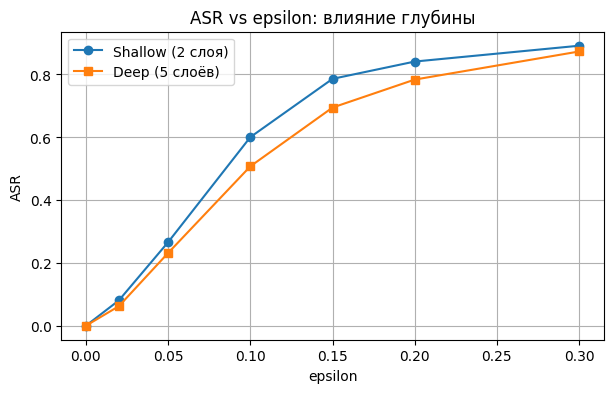

eps=0.00: Shallow=0.000, Deep=0.000
eps=0.02: Shallow=0.080, Deep=0.062
eps=0.05: Shallow=0.266, Deep=0.232
eps=0.10: Shallow=0.600, Deep=0.507
eps=0.15: Shallow=0.786, Deep=0.695
eps=0.20: Shallow=0.841, Deep=0.784
eps=0.30: Shallow=0.891, Deep=0.873


In [17]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"Shallow params: {count_params(shallow_model):,}")
print(f"Deep params: {count_params(deep_model):,}")

asr_shallow = [evaluate_asr(shallow_model, test_loader, e) for e in epsilons]
asr_deep    = [evaluate_asr(deep_model,    test_loader, e) for e in epsilons]

plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_shallow, marker="o", label="Shallow (2 слоя)")
plt.plot(epsilons, asr_deep,    marker="s", label="Deep (5 слоёв)")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("ASR vs epsilon: влияние глубины")
plt.legend(); plt.grid(True); plt.show()

for e, a1, a2 in zip(epsilons, asr_shallow, asr_deep):
    print(f"eps={e:.2f}: Shallow={a1:.3f}, Deep={a2:.3f}")

Глубокая сеть с пятью свёрточными слоями показала более низкий ASR при всех ненулевых ε, хотя её параметров в несколько раз меньше, чем у мелкой. Чистая точность у обеих примерно одинаковая. Разница в ASR заметнее всего при средних значениях бюджета, где глубокая модель обманывается заметно реже. При большом ε обе сети почти сравниваются, потому что возмущение становится слишком сильным.

Это согласуется с идеей иерархии признаков. Глубокая сеть использует комбинации признаков более высокого уровня, а они менее чувствительны к мелким локальным сдвигам, чем простые детекторы краёв в мелкой сети. Дополнительные нелинейные слои затрудняют атаку: градиент, который FGSM использует для построения возмущения, проходит через большее число преобразований и хуже согласуется с решением.

Проще говоря, глубокая сеть чуть устойчивее, но это не спасение. При сильной атаке она обманывается так же легко, как и мелкая.

# C3 Трансферируемость adversarial-примеров
Трансферируемость — это свойство adversarial-примеров, открытое Szegedy и соавторами в 2013 году. Оно состоит в том, что примеры, построенные для одной модели, часто обманывают и другую модель, даже если у неё другая архитектура и она обучалась отдельно.

Почему это работает. Разные нейросети, обученные на одной задаче, учатся похожим признакам. Они по-разному устроены, но все выделяют края, штрихи, текстуры — потому что эти признаки полезны для распознавания. Из-за этого направления градиента у разных моделей оказываются частично согласованными. Возмущение, которое увеличивает лосс одной модели, часто увеличивает лосс и другой.

Практический смысл. Злоумышленник может не знать архитектуру жертвы. Он обучает свою модель, строит для неё adversarial-примеры и применяет к чужой модели. Атака частично срабатывает. Это называется black-box атакой. Трансферируемость делает такие атаки возможными без доступа к весам жертвы.

In [18]:
model_a = shallow_model
model_b = deep_model

print(f"Model A clean acc: {evaluate_accuracy(model_a, test_loader):.4f}")
print(f"Model B clean acc: {evaluate_accuracy(model_b, test_loader):.4f}")

Model A clean acc: 0.9674
Model B clean acc: 0.9656


In [19]:
def transfer_asr(model_a, model_b, loader, epsilon, n_batches=10):
    # Модель А используется только для генерации возмущения
    # Модель Б — жертва, её мы проверяем
    model_a.eval()
    model_b.eval()
    total, fooled = 0, 0
    for i, (x, y) in enumerate(loader):
        # Ограничиваем число батчей для скорости
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)
        # Строим adversarial-пример для модели А
        x_adv = fgsm_attack(model_a, x, y, epsilon)
        # Предсказание модели Б на adversarial-примере
        with torch.no_grad():
            pred_b = model_b(x_adv).argmax(dim=1)
        # Считаем, сколько примеров модель Б распознала неправильно
        fooled += (pred_b != y).sum().item()
        total  += y.size(0)
    return fooled / total

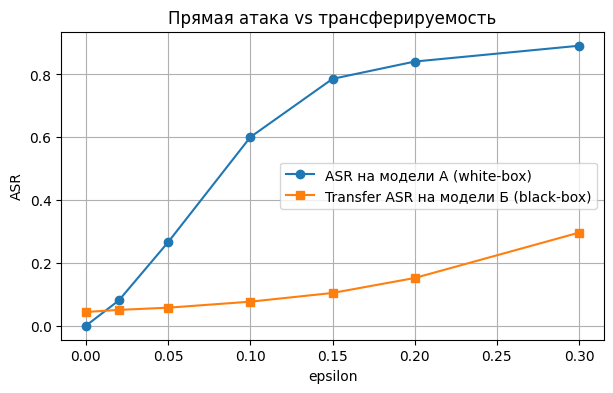

eps=0.00: ASR на А=0.000, Transfer на Б=0.044
eps=0.02: ASR на А=0.080, Transfer на Б=0.050
eps=0.05: ASR на А=0.266, Transfer на Б=0.057
eps=0.10: ASR на А=0.600, Transfer на Б=0.077
eps=0.15: ASR на А=0.786, Transfer на Б=0.104
eps=0.20: ASR на А=0.841, Transfer на Б=0.152
eps=0.30: ASR на А=0.891, Transfer на Б=0.296


In [20]:
# ASR на самой модели А (примеры строились для неё же)
asr_on_a = [evaluate_asr(model_a, test_loader, e) for e in epsilons]

# Transfer ASR: примеры для А, проверяем на Б
asr_transfer = [transfer_asr(model_a, model_b, test_loader, e) for e in epsilons]

# Рисуем два графика
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_on_a,   marker="o", label="ASR на модели А (white-box)")
plt.plot(epsilons, asr_transfer, marker="s", label="Transfer ASR на модели Б (black-box)")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("Прямая атака vs трансферируемость")
plt.legend(); plt.grid(True); plt.show()

for e, a1, a2 in zip(epsilons, asr_on_a, asr_transfer):
    print(f"eps={e:.2f}: ASR на А={a1:.3f}, Transfer на Б={a2:.3f}")

Кривая ASR на модели А идёт заметно выше, чем кривая transfer ASR на модели Б. Это значит, что атака, построенная под конкретную модель, обманывает её гораздо эффективнее, чем чужую. При малых бюджетах разрыв особенно велик: возмущение, которое уверенно ломает модель-источник, на модели-жертве срабатывает лишь частично.
В целом результат подтверждает, что трансферируемость существует и работает, но слабее прямой white-box атаки.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
